In [1]:
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Load dataset
df = sns.load_dataset('tips')
df.head()


,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [2]:
tip_smoker = df[df['smoker'] == 'Yes']['tip']
tip_nonsmoker = df[df['smoker'] == 'No']['tip']


In [3]:
shapiro_smoker = stats.shapiro(tip_smoker)
shapiro_nonsmoker = stats.shapiro(tip_nonsmoker)

print('Perokok p-value:', shapiro_smoker.pvalue)
print('Non-perokok p-value:', shapiro_nonsmoker.pvalue)


Perokok p-value: 3.612564299352561e-07
Non-perokok p-value: 2.0587577392218136e-08


In [4]:
if shapiro_smoker.pvalue > 0.05 and shapiro_nonsmoker.pvalue > 0.05:
    stat, pval = stats.ttest_ind(tip_smoker, tip_nonsmoker, equal_var=False)
    test_used = 'Independent t-test'
else:
    stat, pval = stats.mannwhitneyu(tip_smoker, tip_nonsmoker, alternative='two-sided')
    test_used = 'Mann-Whitney U'

print(test_used)
print('Statistik uji:', stat)
print('p-value:', pval)


Mann-Whitney U
Statistik uji: 7163.0
p-value: 0.7919240198382322


In [5]:
print('Mean tip perokok:', tip_smoker.mean())
print('Mean tip non-perokok:', tip_nonsmoker.mean())


Mean tip perokok: 3.008709677419355
Mean tip non-perokok: 2.9918543046357615


pada tingkat kepercayaan 95% (alpha = 0.05), apakah ada 
perbedaan tip yang signifikan antara perokok dan non-perokok? Apa implikasinya bagi kebijakan restoran?

Tidak, berarti restoran kemungkinan sudah menyediakan ruangan yang berbeda agar tidak terganggung sehingga tiap kategoti memiliki nilai yg mirip.


In [6]:

tip_lunch = df[df['time'] == 'Lunch']['tip']
tip_dinner = df[df['time'] == 'Dinner']['tip']


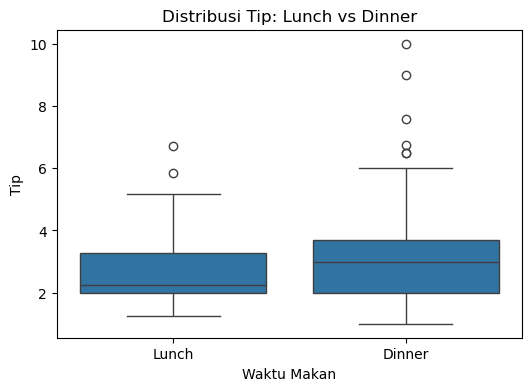

In [7]:

plt.figure(figsize=(6,4))
sns.boxplot(x='time', y='tip', data=df)
plt.title('Distribusi Tip: Lunch vs Dinner')
plt.xlabel('Waktu Makan')
plt.ylabel('Tip')
plt.show()


In [8]:

shapiro_lunch = stats.shapiro(tip_lunch)
shapiro_dinner = stats.shapiro(tip_dinner)

if shapiro_lunch.pvalue > 0.05 and shapiro_dinner.pvalue > 0.05:
    stat, pval = stats.ttest_ind(
        tip_dinner, tip_lunch,
        equal_var=False,
        alternative='greater'
    )
    test_used = 'Independent t-test (one-sided)'
else:
    stat, pval = stats.mannwhitneyu(
        tip_dinner, tip_lunch,
        alternative='greater'
    )
    test_used = 'Mann-Whitney U (one-sided)'

print(test_used)
print('Statistik uji:', stat)
print('p-value:', pval)


Mann-Whitney U (one-sided)
Statistik uji: 7063.0
p-value: 0.014414022838396583


In [9]:

print('Mean Lunch:', tip_lunch.mean())
print('Mean Dinner:', tip_dinner.mean())


Mean Lunch: 2.728088235294118
Mean Dinner: 3.102670454545454


apakah data mendukung hipotesis bahwa tip saat makan malam lebih tinggi? Sertakan angka rata-rata tip untuk masing-masing waktu makan dalam kesimpulan.

ya, p value lebih rentah dari (<) 0.05, sehinga h1 diterima. dimana terdapat perbeddaan tip saat makan malam. untuk rata-rata : 

Mean Lunch: 2.728088235294118

Mean Dinner: 3.102670454545454

In [10]:
pearson = stats.pearsonr(df['total_bill'], df['tip'])
spearman = stats.spearmanr(df['total_bill'], df['tip'])

print('Pearson r:', pearson.statistic, 'p-value:', pearson.pvalue)
print('Spearman r:', spearman.statistic, 'p-value:', spearman.pvalue)


Pearson r: 0.6757341092113646 p-value: 6.69247064686336e-34
Spearman r: 0.6789681219001009 p-value: 2.5011584409235997e-34


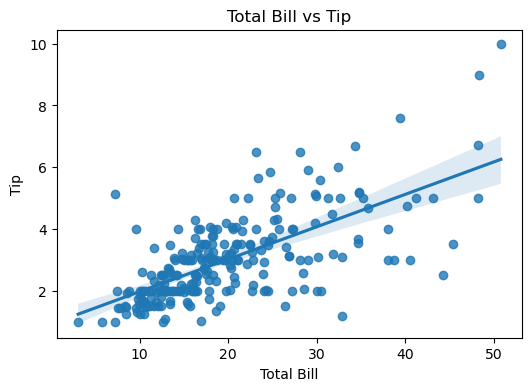

In [11]:
plt.figure(figsize=(6,4))
sns.regplot(x='total_bill', y='tip', data=df)
plt.title('Total Bill vs Tip')
plt.xlabel('Total Bill')
plt.ylabel('Tip')
plt.show()


In [12]:
pearson_size = stats.pearsonr(df['size'], df['tip'])
print('Pearson size vs tip:', pearson_size.statistic)
print('p-value:', pearson_size.pvalue)


Pearson size vs tip: 0.48929877523035725
p-value: 4.3005433272250085e-16


Apakah rombongan yang lebih besar cenderung memberi tip lebih banyak? Sertakan p-value dalam kesimpulan.

Ya, grafiknya juga mendukung terhadap konklusi tersebut, dimana lebih besar rombongannya, lebih besar tipnya. 